In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache
import tqdm
from scipy.ndimage import gaussian_filter1d
import preprocess_data as ppd
import lstm_module as lstm 
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from captum.attr import IntegratedGradients
from torch.utils.data import DataLoader, TensorDataset
import sys
import pandas as pd
import os
import warnings

In [2]:
# Determine if CUDA (GPU) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
warnings.filterwarnings("ignore", message="Ignoring cached namespace")

output_dir = r"Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022"
output_dir = Path(output_dir)
cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=output_dir)
session_id = 1044385384 # Arbitrary pick
session = cache.get_ecephys_session(ecephys_session_id=session_id)
behavior_id = session.behavior_session_id
behavior = cache.get_behavior_session(behavior_id)
chan = session.get_channels()

In [4]:
units = session.get_units()
channels = session.get_channels()
spike_times = session.spike_times
units = units.merge(channels, left_on='peak_channel_id', right_index=True)
units = units[(units.isi_violations < 0.5) &
                                      (units.presence_ratio > 0.9) &
                                      (units.amplitude_cutoff < 0.1) &
                                      (units.firing_rate > 0.1)]

In [6]:
# get the epochs of the behavior session
start = int(behavior.stimulus_presentations.start_time[behavior.stimulus_presentations.active].iloc[0]) - 1 
stop  = int(behavior.stimulus_presentations.end_time[behavior.stimulus_presentations.active].iloc[-1])  + 1
active = [start, stop]

bin_size = 0.004

spikes_obj = ppd.pre_process_spikes(units, spike_times,bin_size=0.004, sigma=3)
spikes_obj.getSpkMat(active[0], active[1])
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()


100%|██████████| 741/741 [01:11<00:00, 10.35it/s]


In [7]:
probeC = session.get_lfp(session.probes[session.probes.name == 'probeC'].index[0])
# channel ids for VISp
visp_df = chan.loc[probeC.channel][chan.loc[probeC.channel]['structure_acronym'].str.contains('VISp')]
num_channels = len(visp_df)
lfp_slice = probeC.sel(time=slice(start,stop), channel=visp_df.index)
# resample data from 1250 Hz to 250 Hz to match the spike data
data = stats.zscore(lfp_slice[::5,:].values, axis=0) 
print(data.shape)
print(spikes_obj.spkMat.shape)
# make sure the data is the same length as the spike data
if data.shape[0] > spikes_obj.spkMat.shape[0]:
    data = data[:spikes_obj.spkMat.shape[0],:]

(901252, 20)
(901250, 741)


In [88]:
class SpikingTransformer(nn.Module):
    def __init__(self, num_neurons, embedding_dim, num_heads, num_layers, dropout=0.1):
        super(SpikingTransformer, self).__init__()

        self.num_neurons = num_neurons
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.num_layers = num_layers

        # Embedding Layer:  Maps spike counts to a higher-dimensional space
        self.embedding = nn.Linear(num_neurons, embedding_dim)
        self.embedding_bn = nn.BatchNorm1d(embedding_dim) # Batchnorm after embedding

        # Positional Encoding (Learnable)
        self.positional_embedding = nn.Embedding(750, embedding_dim)  # Window size is 750

        # Transformer Encoder Layers
        self.transformer_encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dropout=dropout,
            batch_first=True # Important for PyTorch >= 1.9
        )
        self.transformer_encoder = nn.TransformerEncoder(
            self.transformer_encoder_layer,
            num_layers=num_layers
        )

        # Regression Head
        self.regression_head = nn.Linear(embedding_dim, 1)  # Predicts a single LFP value

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Args:
            x:  Input spike counts, shape (batch_size, sequence_length, num_neurons)
        Returns:
            lfp_predictions: Predicted LFP values, shape (batch_size, sequence_length)
        """
        batch_size, seq_len, _ = x.shape

        # Embedding
        embedded = self.embedding(x)  # (batch_size, sequence_length, embedding_dim)
        #Reshape is required before applying batch norm!
        embedded = embedded.permute(0,2,1)
        embedded = self.embedding_bn(embedded)
        embedded = embedded.permute(0,2,1)
        embedded = self.dropout(embedded)

        # Positional Encoding
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)  # (batch_size, sequence_length)
        positional_embeddings = self.positional_embedding(positions) # (batch_size, sequence_length, embedding_dim)
        embedded += positional_embeddings

        # Transformer Encoder
        transformer_output = self.transformer_encoder(embedded) # (batch_size, sequence_length, embedding_dim)

        # Regression Head
        lfp_predictions = self.regression_head(transformer_output).squeeze(-1)  # (batch_size, sequence_length)

        return lfp_predictions


def chunk_and_reshape(spikes, lfp, seqlength, test_size=0.2, random_state=42):
    """
    Chunks the spike and LFP data into equal segments, reshapes them,
    and splits them into training and testing sets.

    Args:
        spikes: NumPy array of shape (num_timepoints, num_neurons) representing spiking data.
        lfp: NumPy array of shape (num_timepoints, num_lfp_channels) representing LFP data.
             If LFP is single channel, should be (num_timepoints, 1).
        seqlength: The length of each chunk (window size).
        test_size: The proportion of data to use for the test set.
        random_state: The random state for the train_test_split function.

    Returns:
        X_train, X_test, y_train, y_test: NumPy arrays representing the training and testing sets
                                         for the spikes (X) and LFP (y) data.
    """

    num_trials = int(lfp.shape[0] / seqlength)

    # Truncate spikes and LFP data to be multiples of seqlength
    spikes = spikes[:num_trials * seqlength, :]
    lfp = lfp[:num_trials * seqlength, :]

    # Reshape the data into trials
    X_reshaped = np.reshape(spikes, (num_trials, seqlength, spikes.shape[1]))
    lfp_reshaped = np.reshape(lfp, (num_trials, seqlength, lfp.shape[1]))

    # Split into training and testing sets at the trial level
    X_train, X_test, y_train, y_test = train_test_split(
        X_reshaped, lfp_reshaped, test_size=test_size, random_state=random_state
    )

    return X_train, X_test, y_train, y_test


In [97]:
# Example Usage
num_neurons = spikes_obj.spkMat.shape[1]  # Number of neurons
num_timepoints = spikes_obj.spkMat.shape[0]  # Total timepoints
seqlength = 750  # Length of each chunk
num_lfp_channels = 1 # number of lfp channels

# Generate some synthetic data
spikes = spikes_obj.spkMat 
lfp = data[:,5]
lfp = lfp[:, np.newaxis]  # Make LFP data 2D to be (num_timepoints, 1)

# Parameters for chunking and reshaping
test_size = 0.2
random_state = 42

# Chunk, Reshape, and Split
X_train, X_test, y_train, y_test = chunk_and_reshape(
    spikes, lfp, seqlength, test_size, random_state
)

# Convert to PyTorch tensors and move to GPU
X_train = torch.from_numpy(X_train).float().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)


# Create DataLoader for batching
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Hyperparameters
embedding_dim = 64
num_heads = 8
num_layers = 4
learning_rate = 0.001
num_epochs = 10

In [98]:
# Initialize the model
model = SpikingTransformer(num_neurons=num_neurons,
                            embedding_dim=embedding_dim,
                            num_heads=num_heads,
                            num_layers=num_layers).to(device)  # Move model to GPU

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)   

# --- Loss Tracking ---
train_losses = np.zeros(num_epochs)
test_losses = np.zeros(num_epochs)
# --- End Loss Tracking ---

# Training Loop
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    for batch_idx, (X_batch, y_batch) in enumerate(train_dataloader):
        # Move data to GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        y_pred = model(X_batch) # (batch_size, seqlength)

        # Compute the loss. Note: Reshape y_batch if necessary to match the shape of y_pred
        loss = criterion(y_pred, y_batch.squeeze()) #Squeeze to remove unnecessary dimension
        total_train_loss += loss.item()

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (batch_idx + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_dataloader)}], Loss: {loss.item():.4f}')

    # Average training loss for the epoch
    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses[epoch] = avg_train_loss  # Store training loss
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Training Loss: {avg_train_loss:.4f}')


    # Evaluation on Test Set after each epoch
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch_idx, (X_batch, y_batch) in enumerate(test_dataloader):
            # Move data to GPU
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch.squeeze())
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_dataloader)
    test_losses[epoch] = avg_test_loss  # Store test loss
    print(f'Epoch [{epoch+1}/{num_epochs}], Test Loss: {avg_test_loss:.4f}')

print("Training Complete!")


Epoch [1/10], Batch [10/30], Loss: 1.0573
Epoch [1/10], Batch [20/30], Loss: 1.2553
Epoch [1/10], Batch [30/30], Loss: 0.9883
Epoch [1/10], Average Training Loss: 1.7518
Epoch [1/10], Test Loss: 0.9634
Epoch [2/10], Batch [10/30], Loss: 0.8790
Epoch [2/10], Batch [20/30], Loss: 1.0185
Epoch [2/10], Batch [30/30], Loss: 0.8990
Epoch [2/10], Average Training Loss: 1.0205
Epoch [2/10], Test Loss: 0.9409
Epoch [3/10], Batch [10/30], Loss: 1.0479
Epoch [3/10], Batch [20/30], Loss: 1.1060
Epoch [3/10], Batch [30/30], Loss: 0.9614
Epoch [3/10], Average Training Loss: 1.0150
Epoch [3/10], Test Loss: 0.9374
Epoch [4/10], Batch [10/30], Loss: 1.0753
Epoch [4/10], Batch [20/30], Loss: 0.9357
Epoch [4/10], Batch [30/30], Loss: 0.8875
Epoch [4/10], Average Training Loss: 0.9848
Epoch [4/10], Test Loss: 0.7067
Epoch [5/10], Batch [10/30], Loss: 0.6870
Epoch [5/10], Batch [20/30], Loss: 0.5731
Epoch [5/10], Batch [30/30], Loss: 0.6122
Epoch [5/10], Average Training Loss: 0.6353
Epoch [5/10], Test Los

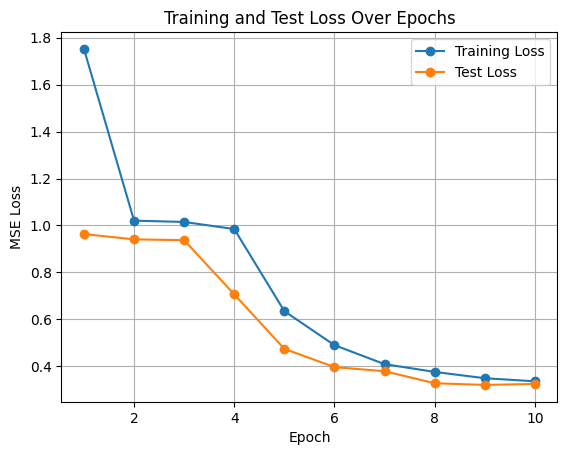

In [99]:
epochs = range(1, num_epochs + 1) # Create x-axis values (epochs)

plt.plot(epochs, train_losses,'o-', label='Training Loss')
plt.plot(epochs, test_losses,'o-', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Test Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [100]:
# first 30 seconds
spikes = spikes[:750*10, :]
lfp = lfp[:750*10, :]
# Reshape the data into trials
X_reshaped = np.reshape(spikes, (10, seqlength, spikes.shape[1]))
y_pred = model(torch.from_numpy(X_reshaped).float().to(device))
# reshape the data back to the original shape
y_pred = y_pred.detach().cpu().numpy()
y_pred = np.reshape(y_pred, (y_pred.shape[0] * y_pred.shape[1],))

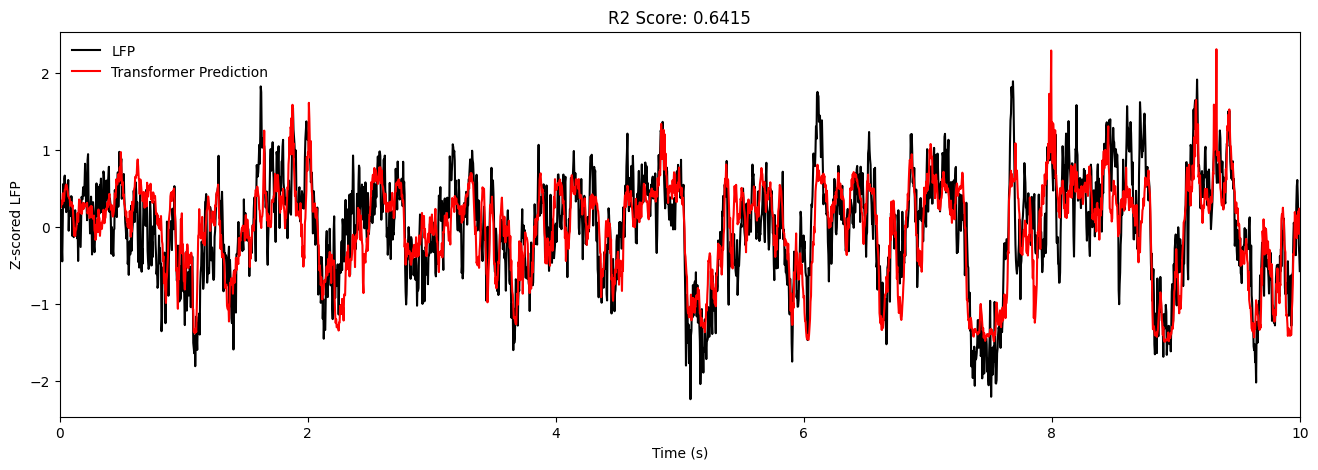

In [115]:

fig, ax = plt.subplots(1,1, figsize=(16, 5))
ax.plot(np.linspace(0,10,int(10/bin_size)), lfp[:int(10/bin_size)],'k',label='LFP')
ax.plot(np.linspace(0,10,int(10/bin_size)), y_pred[:int(10/bin_size)],'r',label='Transformer Prediction')
ax.set_xlabel('Time (s)')
ax.set_xlim([0,10])
ax.set_ylabel('Z-scored LFP')
ax.legend(loc='upper left', frameon=False)
r2 = r2_score(lfp, y_pred)
ax.set_title(f'R2 Score: {r2:.4f}')
plt.show()


In [102]:
start = behavior.stimulus_presentations.start_time[behavior.stimulus_presentations.stimulus_name == 'spontaneous'].iloc[-1]
stop  = behavior.stimulus_presentations.end_time[behavior.stimulus_presentations.stimulus_name == 'spontaneous'].iloc[-1]
spontaneous = [start, stop]

spikes_obj_spont = ppd.pre_process_spikes(units, spike_times,bin_size=0.004, sigma=3)
spikes_obj_spont.getSpkMat(spontaneous[0], spontaneous[1])
spikes_obj_spont.convolve_with_gaussian()
spikes_obj_spont.zscore()

lfp_slice = probeC.sel(time=slice(spontaneous[0], spontaneous[1]), channel=visp_df.index)
# resample data from 1250 Hz to 250 Hz to match the spike data
spont_data = stats.zscore(lfp_slice[::5,:].values, axis=0) 
print(spont_data.shape)
print(spikes_obj_spont.spkMat.shape)
# make sure the data is the same length as the spike data
if spont_data.shape[0] > spikes_obj_spont.spkMat.shape[0]:
    spont_data = spont_data[:spikes_obj_spont.spkMat.shape[0],:]

100%|██████████| 741/741 [00:05<00:00, 134.92it/s]


(72248, 20)
(72248, 741)


In [103]:
spont_lfp = spont_data[:,5]
spont_lfp = spont_lfp[:, np.newaxis]  # Make LFP data 2D to be (num_timepoints, 1)
num_trials = int(spont_lfp.shape[0] / seqlength)
# Truncate spikes and LFP data to be multiples of seqlength
spikes = spikes_obj_spont.spkMat[:num_trials * seqlength, :]
spont_lfp = spont_lfp[:num_trials * seqlength, :]

# Reshape the data into trials
X_spont = np.reshape(spikes, (num_trials, seqlength, spikes.shape[1]))

y_pred_spont = model(torch.from_numpy(X_spont).float().to(device))
y_pred_spont = y_pred_spont.detach().cpu().numpy()
y_pred_spont = np.reshape(y_pred_spont, (y_pred_spont.shape[0] * y_pred_spont.shape[1],))



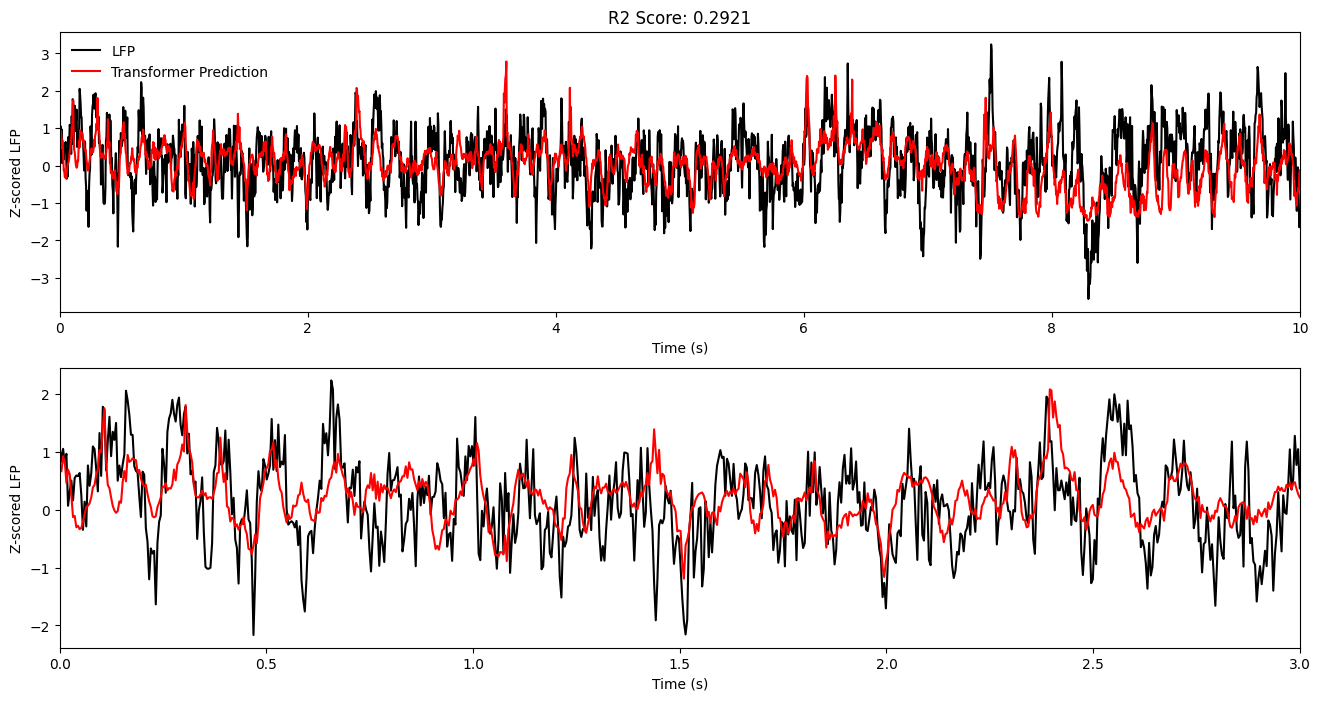

In [118]:

fig, ax = plt.subplots(2,1, figsize=(16, 8))
ax[0].plot(np.linspace(0,10,int(10/bin_size)), spont_lfp[:int(10/bin_size)],'k',label='LFP')
ax[0].plot(np.linspace(0,10,int(10/bin_size)), y_pred_spont[:int(10/bin_size)],'r',label='Transformer Prediction')
ax[0].set_xlabel('Time (s)')
ax[0].set_xlim([0,10])
ax[0].set_ylabel('Z-scored LFP')
ax[0].legend(loc='upper left', frameon=False)
r2 = r2_score(spont_lfp, y_pred_spont)
ax[0].set_title(f'R2 Score: {r2:.4f}')

ax[1].plot(np.linspace(0,3,int(3/bin_size)), spont_lfp[:int(3/bin_size)],'k',label='LFP')
ax[1].plot(np.linspace(0,3,int(3/bin_size)), y_pred_spont[:int(3/bin_size)],'r',label='Transformer Prediction')
ax[1].set_xlabel('Time (s)')
ax[1].set_xlim([0,3])
ax[1].set_ylabel('Z-scored LFP')
plt.tight_layout
plt.show()

